In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy.linalg import norm

In [3]:
Z = np.random.multinomial(1, [0.5, 0.5], size=2)

In [5]:
np.argmax(Z, axis=1)

array([0, 0])

In [2]:
# generate the data under the null
def generate_gaussian_data(n, k, sigma, edge_var=1, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    I_d = np.eye(k)
    R = np.block([
            [I_d,          sigma * I_d],
            [sigma * I_d,  I_d        ]
        ])
    
    q = np.random.multivariate_normal(np.zeros(2*k), R, size=n)
    Z = q[:, :k]
    X = q[:, k:]

    A = rng.normal(loc=Z @ Z.T, scale=edge_var)
    B = rng.normal(loc=X @ X.T, scale=edge_var)
    # symmetrise
    A = (A + A.T) / 2 
    B = (B + B.T) / 2
    
    return A, B, Z, X

def solve_independent(A, k=2):
    evals, evectors = eigsh(A, k=k, which='LM')
    evals = np.maximum(evals-0.5, 0)
    xhat = evectors @ np.diag(np.sqrt(evals))
    return xhat, evals

def rv_coefficient(A, B):
    num = np.trace((A.T @ B) @ (B.T @ A))
    den = norm(A.T @ A, 'fro') * norm(B.T @ B, 'fro')
    return num / den if den != 0 else 0

In [3]:
rng = np.random.default_rng(1)
n = 2000
k = 2
edge_var = 1
sigma = 0

A, B, Z, X = generate_gaussian_data(n, k, sigma, edge_var=edge_var, rng=rng)

Zhat, evals_A = solve_independent(A, k=k)
Xhat, evals_B = solve_independent(B, k=k)

rv_coefficient(A, B), rv_coefficient(Zhat, Xhat), rv_coefficient(Z, X)

(np.float64(0.0015210500230806883),
 np.float64(0.0010042729187362015),
 np.float64(0.0010219561356132605))

In [74]:
nsim = 10
nnodes = np.array([1e2, 5e2, 1e3, 2e3]).astype(int)
k = 3
sigma = 0
edge_var = 10
res_x = {}
res_z = {}
rng = np.random.default_rng(1)
for nodes in nnodes:    
    err_x = []
    err_z = []
    for i in range(nsim):
        A, B, Z, X = generate_gaussian_data(nodes, k, sigma=sigma, edge_var=edge_var, rng=rng)
        Zhat, evals_A = solve_independent(A, k=k)
        Xhat, evals_B = solve_independent(B, k=k)
        err_x.append(((X@X.T-Xhat@Xhat.T)**2).mean())
        err_z.append(((Z@Z.T-Zhat@Zhat.T)**2).mean())
    res_x[nodes] = np.mean(err_x)
    res_z[nodes] = np.mean(err_z)

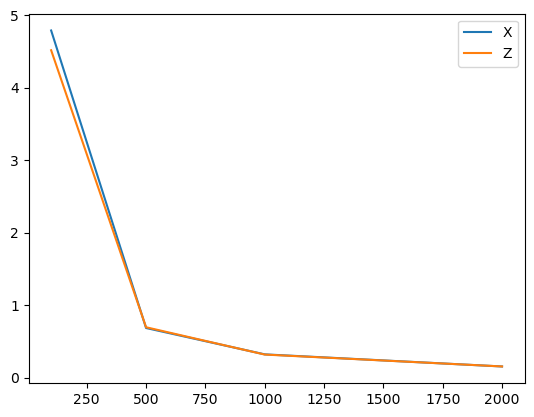

In [75]:
fig, ax = plt.subplots(1, 1)
ax.plot(res_x.keys(), res_x.values(), label='X')
ax.plot(res_z.keys(), res_z.values(), label='Z')
plt.legend()
plt.show()

In [69]:
rng = np.random.default_rng(1)
n = 50
k = 5
edge_var = 5
sigma = 0

A, B, Z, X = generate_gaussian_data(n, k, sigma, edge_var=edge_var, rng=rng)

Zhat, evals_A = solve_independent(A, k=k)
Xhat, evals_B = solve_independent(B, k=k)
rv_est = rv_coefficient(Zhat, Xhat)
rv_coefficient(A, B), rv_coefficient(Zhat, Xhat), rv_coefficient(Z, X)

(np.float64(0.3129229505854871),
 np.float64(0.0781035143049594),
 np.float64(0.07580881009443535))

In [70]:
n_perm = 100
rv_distr = []
for i in range(n_perm):
    perm = rng.permutation(n)
    X_perm = X[perm, :]
    rv_perm = rv_coefficient(X_perm, Z)
    rv_distr.append(rv_perm)

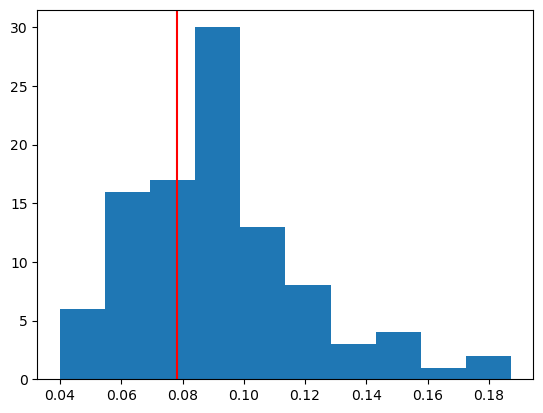

In [71]:
fig, ax = plt.subplots()
ax.hist(rv_distr)
ax.axvline(rv_est, color='red')
plt.show()